# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech (Human Resources)

- Nama: Galih Permana Sidik
- Email: cdcc596d6y2645@student.devacademy.id
- Id Dicoding: cdcc596d6y2645

## Persiapan

### Menyiapkan library yang dibutuhkan

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)
import joblib

sns.set_style('whitegrid')
%matplotlib inline


### Menyiapkan data yang akan diguankan

In [5]:
df = pd.read_csv('employee_data.csv')
df.head()


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

Dataset ini berisi data karyawan perusahaan **Jaya Jaya Maju** (perusahaan bidang edutech) sejumlah 1.470 baris dengan 35 kolom, mencakup atribut demografis (Age, Gender, MaritalStatus), atribut pekerjaan (Department, JobRole, JobLevel, MonthlyIncome, OverTime, BusinessTravel), serta atribut kepuasan kerja (JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance, dsb).

Kolom **Attrition** adalah target yang menandakan apakah karyawan tersebut resign (1) atau tidak (0). Terdapat 412 baris dengan nilai Attrition kosong (NaN) — baris inilah yang nantinya akan diprediksi menggunakan model yang dibangun dari 1.058 baris berlabel.

In [6]:
print('Jumlah baris & kolom:', df.shape)
df.info()


Jumlah baris & kolom: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470

In [7]:
print('Jumlah data yang belum berlabel (Attrition kosong):', df['Attrition'].isna().sum())
df.isna().sum()[df.isna().sum() > 0]


Jumlah data yang belum berlabel (Attrition kosong): 412


,0
Attrition,412


In [8]:
df.describe()


,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
df['Attrition'].value_counts(dropna=False)


,count
Attrition,
0.0,879
NaN,412
1.0,179


### Exploratory Data Analysis (EDA)

Berikut analisis awal untuk memahami faktor-faktor yang berhubungan dengan attrition, menggunakan subset data yang sudah berlabel.

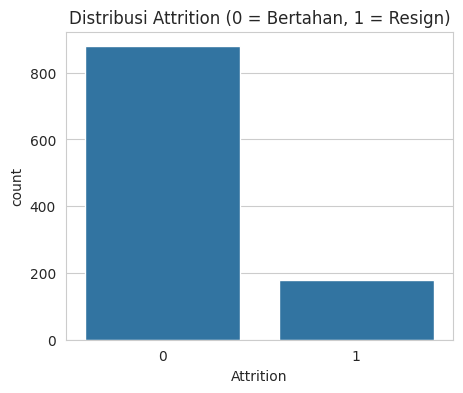

Attrition rate keseluruhan: 16.92 %


In [10]:
labeled = df.dropna(subset=['Attrition']).copy()
labeled['Attrition'] = labeled['Attrition'].astype(int)

plt.figure(figsize=(5,4))
sns.countplot(data=labeled, x='Attrition')
plt.title('Distribusi Attrition (0 = Bertahan, 1 = Resign)')
plt.show()

print('Attrition rate keseluruhan:', round(labeled['Attrition'].mean()*100, 2), '%')


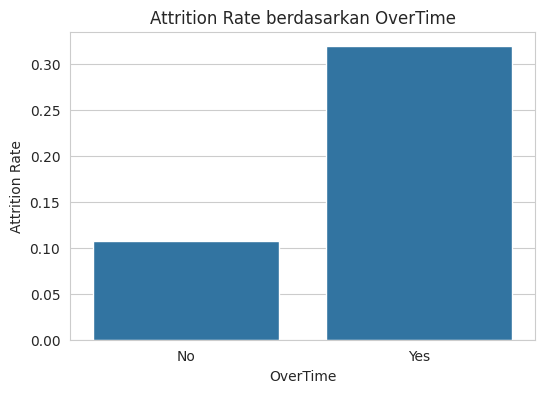

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(data=labeled, x='OverTime', y='Attrition', errorbar=None)
plt.title('Attrition Rate berdasarkan OverTime')
plt.ylabel('Attrition Rate')
plt.show()


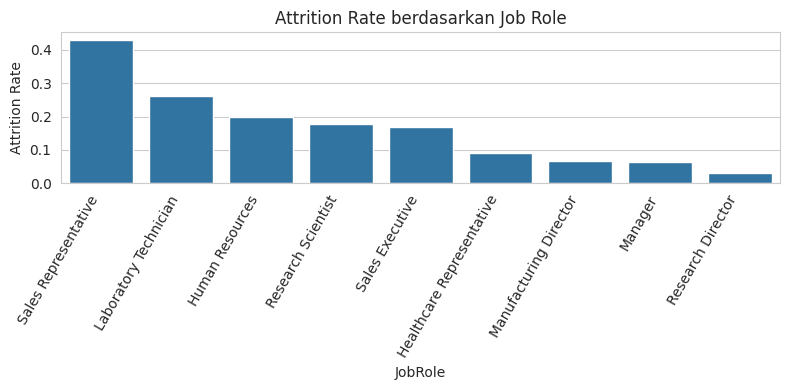

In [12]:
plt.figure(figsize=(8,4))
order = labeled.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False).index
sns.barplot(data=labeled, x='JobRole', y='Attrition', order=order, errorbar=None)
plt.title('Attrition Rate berdasarkan Job Role')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


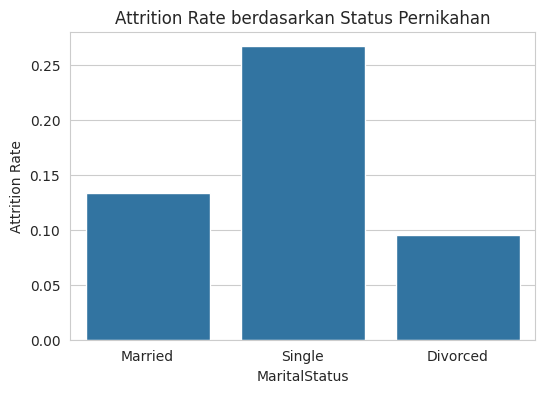

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(data=labeled, x='MaritalStatus', y='Attrition', errorbar=None)
plt.title('Attrition Rate berdasarkan Status Pernikahan')
plt.ylabel('Attrition Rate')
plt.show()


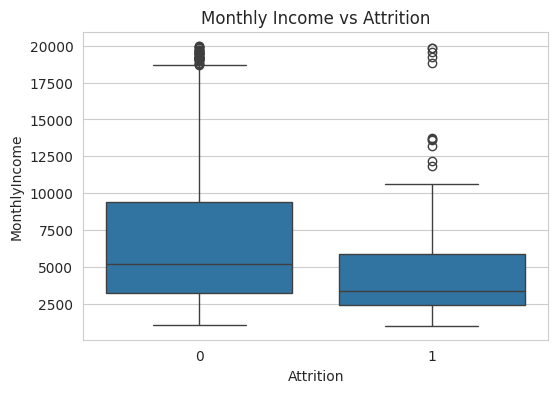

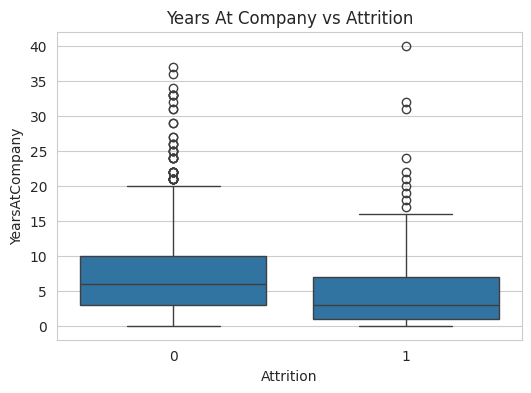

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(data=labeled, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income vs Attrition')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=labeled, x='Attrition', y='YearsAtCompany')
plt.title('Years At Company vs Attrition')
plt.show()


In [15]:
num_cols = labeled.select_dtypes(include='number').columns.drop(['Attrition','EmployeeId','EmployeeCount','StandardHours'])
corr = labeled[list(num_cols) + ['Attrition']].corr()['Attrition'].sort_values()
corr


,Attrition
TotalWorkingYears,-0.177137
Age,-0.172067
JobLevel,-0.169201
StockOptionLevel,-0.164228
MonthlyIncome,-0.163600
YearsInCurrentRole,-0.158757
YearsWithCurrManager,-0.155962
JobInvolvement,-0.150196
YearsAtCompany,-0.135134
EnvironmentSatisfaction,-0.132848


**Insight EDA:**
- Attrition rate keseluruhan sekitar 17% dari data berlabel.
- Karyawan dengan **OverTime = Yes** memiliki attrition rate jauh lebih tinggi (~32%) dibanding yang tidak lembur (~11%).
- **Sales Representative** dan **Laboratory Technician** memiliki attrition rate tertinggi di antara job role.
- Karyawan **Single** lebih rentan resign dibanding yang menikah/bercerai.
- Semakin tinggi **MonthlyIncome**, **JobLevel**, **TotalWorkingYears**, dan **YearsAtCompany**, semakin rendah kecenderungan attrition (korelasi negatif).

## Data Preparation / Preprocessing

In [16]:
df_model = df.copy()

# Kolom yang tidak relevan untuk modeling (konstan / identifier)
employee_ids = df_model['EmployeeId']
drop_cols = ['EmployeeId', 'EmployeeCount', 'StandardHours', 'Over18']
df_model = df_model.drop(columns=drop_cols)

# Pisahkan data berlabel (untuk training) dan data tidak berlabel (untuk diprediksi)
train_df = df_model.dropna(subset=['Attrition']).copy()
predict_df = df_model[df_model['Attrition'].isna()].copy()

train_df['Attrition'] = train_df['Attrition'].astype(int)

# Simpan salinan data prediksi dengan label kategori asli (untuk pelaporan/dashboard)
predict_df_original = predict_df.copy()
predict_df_original.insert(0, 'EmployeeId', employee_ids.loc[predict_df_original.index])

print('Data training:', train_df.shape)
print('Data untuk diprediksi:', predict_df.shape)


Data training: (1058, 31)
Data untuk diprediksi: (412, 31)


In [17]:
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
if not cat_cols:
    cat_cols = [c for c in train_df.columns if train_df[c].dtype == 'str' or train_df[c].dtype == object]
print('Kolom kategorikal:', cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], predict_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    predict_df[col] = le.transform(predict_df[col].astype(str))
    encoders[col] = le

joblib.dump(encoders, 'encoders.joblib')


Kolom kategorikal: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


['encoders.joblib']

In [18]:
X = train_df.drop(columns=['Attrition'])
y = train_df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.joblib')
joblib.dump(list(X.columns), 'feature_columns.joblib')

X_train.shape, X_test.shape


((846, 30), (212, 30))

## Modeling

In [19]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_scaled, y_train)

joblib.dump(model, 'model_attrition.joblib')


['model_attrition.joblib']

## Evaluation

In [20]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred), 3))
print('Recall   :', round(recall_score(y_test, y_pred), 3))
print('F1-score :', round(f1_score(y_test, y_pred), 3))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred))


Accuracy : 0.858
Precision: 0.714
Recall   : 0.278
F1-score : 0.4
ROC-AUC  : 0.781

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       176
           1       0.71      0.28      0.40        36

    accuracy                           0.86       212
   macro avg       0.79      0.63      0.66       212
weighted avg       0.84      0.86      0.83       212



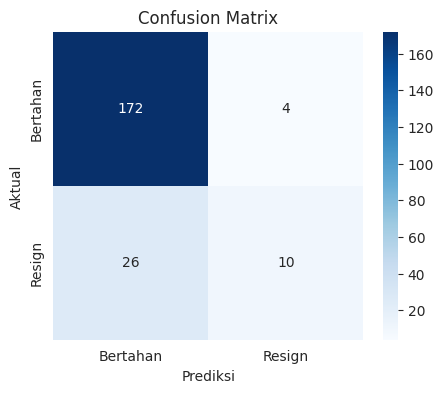

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bertahan','Resign'], yticklabels=['Bertahan','Resign'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


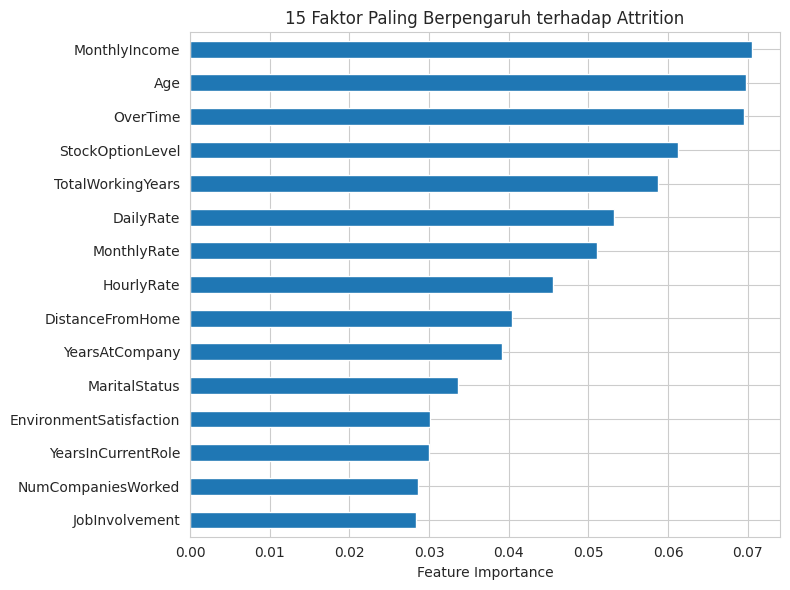

,0
MonthlyIncome,0.070509
Age,0.069729
OverTime,0.069502
StockOptionLevel,0.061240
TotalWorkingYears,0.058779
DailyRate,0.053176
MonthlyRate,0.051114
HourlyRate,0.045493
DistanceFromHome,0.040411
YearsAtCompany,0.039140


In [22]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('15 Faktor Paling Berpengaruh terhadap Attrition')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

importances.head(15)


In [23]:
# Prediksi attrition untuk 412 karyawan yang belum berlabel
X_predict = predict_df.drop(columns=['Attrition'])
X_predict_scaled = scaler.transform(X_predict)

predict_df_original['Attrition_Predicted'] = model.predict(X_predict_scaled)
predict_df_original['Attrition_Probability'] = model.predict_proba(X_predict_scaled)[:, 1]

print('Prediksi jumlah karyawan yang berpotensi resign:', predict_df_original['Attrition_Predicted'].sum())
predict_df_original[['Attrition_Predicted','Attrition_Probability']].head()


Prediksi jumlah karyawan yang berpotensi resign: 23


,Attrition_Predicted,Attrition_Probability
0,0,0.259822
4,0,0.077431
5,0,0.461130
12,0,0.237834
18,0,0.059103


In [24]:
predict_df_original.to_csv('predicted_attrition.csv', index=False)
print('Hasil prediksi disimpan ke predicted_attrition.csv')


Hasil prediksi disimpan ke predicted_attrition.csv


### Kesimpulan Modeling

Model **Random Forest Classifier** yang dibangun mampu memprediksi attrition karyawan dengan performa yang cukup baik (lihat metrik evaluasi di atas). Berdasarkan feature importance, faktor-faktor yang paling berpengaruh terhadap attrition antara lain: **OverTime**, **MonthlyIncome**, **Age**, **TotalWorkingYears**, **JobRole**, **DistanceFromHome**, **JobLevel**, **StockOptionLevel**, **YearsAtCompany**, dan **JobSatisfaction**.

Model ini juga digunakan untuk memprediksi 412 karyawan yang datanya belum memiliki label attrition, sehingga departemen HR dapat memprioritaskan employee retention program pada karyawan-karyawan dengan probabilitas resign tertinggi.

Model (`model_attrition.joblib`), scaler (`scaler.joblib`), encoder kategori (`encoders.joblib`), dan daftar kolom fitur (`feature_columns.joblib`) disimpan agar dapat digunakan kembali pada dashboard/aplikasi prediksi (Streamlit) tanpa perlu melatih ulang model.